In [2]:
# -*- coding: utf-8 -*-
from odbAccess import openOdb
from abaqusConstants import ELEMENT_NODAL
import numpy as np
import csv
import os

# --- Settings ---
odb_path = r'..\..\1.0-First delta flume\Job-amptest-1200.odb'
output_csv = 'max_principal_stress_per_block2.csv'

# --- Open ODB ---
if not os.path.exists(odb_path):
    raise IOError("ODB file not found: {}".format(odb_path))

odb = openOdb(odb_path)
step = odb.steps[odb.steps.keys()[-1]]  # Use the last step
frames = step.frames
all_instances = odb.rootAssembly.instances

# --- Filter all block instances (names start with "BLOCK") ---
block_names = [name for name in all_instances.keys() if name.startswith('BLOCK')]
block_names.sort()  # Optional: sort alphabetically

# --- Prepare output table ---
header = ['Time'] + block_names
rows = []

for frame_idx, frame in enumerate(frames):
    time = round(frame.frameValue, 2)
    print("time step: {:.4f}".format(time))
    stress_field = frame.fieldOutputs['S']
    row = [time]

    for block_name in block_names:
        print("Processing block:", block_name)
        instance = all_instances[block_name]
        stress_subset = stress_field.getSubset(region=instance, position=ELEMENT_NODAL)

        max_princ = -1e20
        for val in stress_subset.values:
            s = val.data
            stress_tensor = np.array([
                [s[0], s[3], s[4]],
                [s[3], s[1], s[5]],
                [s[4], s[5], s[2]]
            ])
            principal_stresses = np.linalg.eigvalsh(stress_tensor)
            max_p = max(principal_stresses)
            if max_p > max_princ:
                max_princ = max_p

        row.append(max_princ if max_princ > -1e10 else '')

    rows.append(row)

odb.close()

# --- Write to CSV ---
with open(output_csv, 'w') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print("\n✅ Done. Max principal stress per block saved to '{}'".format(output_csv))


ModuleNotFoundError: No module named 'odbAccess'

✅ Saved: block_grid_halfblock_225mm.png


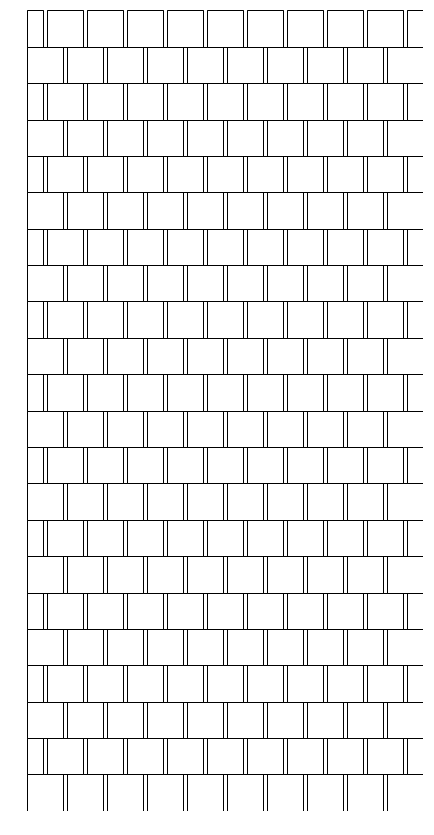

In [7]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


# --- Block properties ---
full_w, full_h = 0.5, 0.5       # full block size
half_w, half_h = 0.225, 0.5     # rotated half block: 0.225m wide, 0.5m high
horizontal_spacing = 0.05
vertical_spacing = 0.0
rows = 22

# --- Start figure ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0  # y-position of bottom of current row

for row in range(rows):
    if row % 2 == 0:
        # Even row: 10 full blocks
        for i in range(10):
            x = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor='white')
            ax.add_patch(rect)
    else:
        # Odd row: half + 9 full + half
        x = 0
        # First half block
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor='white')
        ax.add_patch(rect)
        x += half_w + horizontal_spacing
        # 9 full blocks
        for i in range(9):
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor='white')
            ax.add_patch(rect)
            x += full_w + horizontal_spacing
        # Final half block
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor='white')
        ax.add_patch(rect)

    # Move up to next row
    current_y += full_h + vertical_spacing

# --- Configure plot ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)  # extend to cover last half block
ax.set_ylim(0, current_y)
ax.axis('off')

plt.tight_layout()
plt.savefig("block_grid_halfblock_225mm.png")
print("✅ Saved: block_grid_halfblock_225mm.png")


✅ Saved: stress_blocks_t6.03s.png


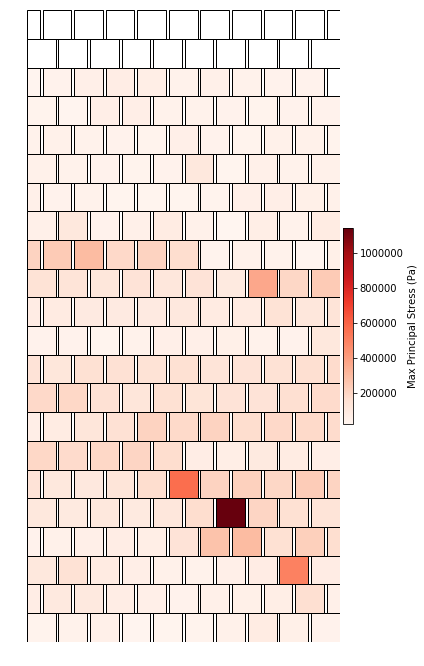

In [8]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np

# --- Settings ---
csv_path = 'max_principal_stress_per_block2.csv'
target_time = 6.03  # Time (s) to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)
df['Time'] = df['Time'].round(2)  # Round time for matching
row = df[df['Time'] == round(target_time, 2)]

if row.empty:
    raise ValueError("⛔ Time step {:.2f} not found in CSV.".format(target_time))

block_data = row.drop(columns='Time').iloc[0]
block_names = block_data.index.tolist()
block_values = block_data.values.astype(float)

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_values), vmax=np.nanmax(block_values))
cmap = plt.cm.Reds

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0
block_index = 0

for row_num in range(rows):
    if row_num % 2 == 0:
        # Even rows: 10 full blocks
        for i in range(10):
            x = i * (full_w + h_spacing)
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
    else:
        x = 0
        # First half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1
        x += half_w + h_spacing
        # 9 full blocks
        for i in range(9):
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
            x += full_w + h_spacing
        # Final half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1

    current_y += full_h + v_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)
ax.set_ylim(0, current_y)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Max Principal Stress (Pa)')

# --- Save figure ---
plt.tight_layout()
out_name = f"stress_blocks_t{target_time:.2f}s.png"
plt.savefig(out_name, dpi=300)
print("✅ Saved:", out_name)


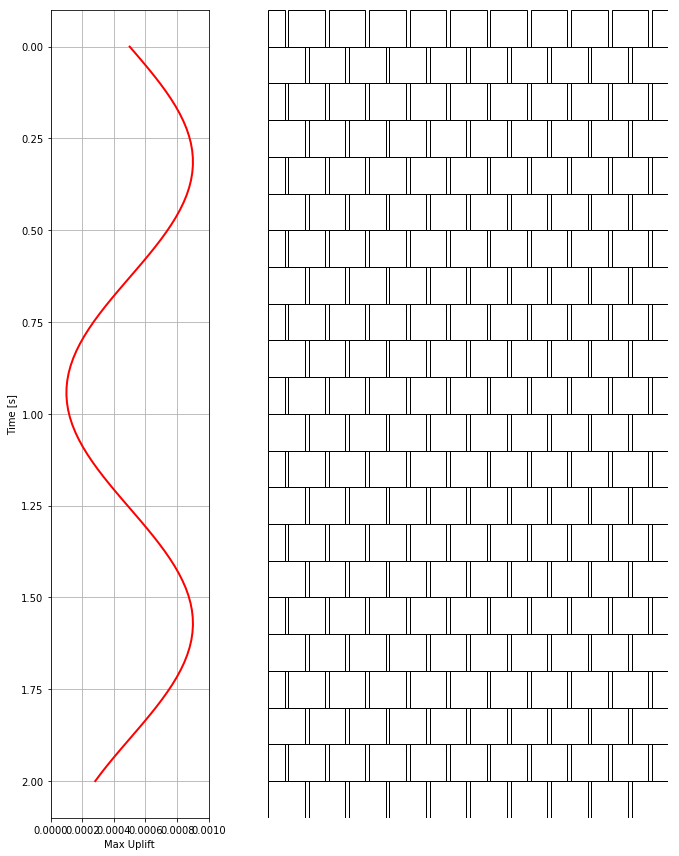

✅ Saved: block_grid_with_side_plot.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# ------------------------------
# Dummy uplift data for example
# ------------------------------
import numpy as np

times = np.linspace(0, 2, 100)
max_uplift = np.sin(times * 5) * 0.0004 + 0.0005   # dummy data

# ------------------------------
# Figure with gridspec
# ------------------------------

# Create figure
fig = plt.figure(figsize=(10, 12))  # wider to fit side plot

# Define gridspec:
#  - 1 row
#  - 2 columns (one narrow for side plot)
gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[1, 3])

# === SIDE AXES: vertical uplift plot ===
ax_left = fig.add_subplot(gs[0, 0])

# Plot uplift vs time, flipped
ax_left.plot(max_uplift, times, color='red', linewidth=2)

# Flip y-axis so time runs from bottom up
ax_left.invert_yaxis()

ax_left.set_xlabel('Max Uplift')
ax_left.set_ylabel('Time [s]')
ax_left.grid(True)

# Optional: limit range for clarity
ax_left.set_xlim(0, 0.001)

# === RIGHT AXES: block grid ===
ax_right = fig.add_subplot(gs[0, 1])

# --- Block properties ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
horizontal_spacing = 0.05
vertical_spacing = 0.0
rows = 22

current_y = 0

for row in range(rows):
    if row % 2 == 0:
        # Even row: 10 full blocks
        for i in range(10):
            x = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle((x, current_y), full_w, full_h,
                                     edgecolor='black', facecolor='white')
            ax_right.add_patch(rect)
    else:
        x = 0
        # First half block
        rect = patches.Rectangle((x, current_y), half_w, half_h,
                                 edgecolor='black', facecolor='white')
        ax_right.add_patch(rect)
        x += half_w + horizontal_spacing
        # 9 full blocks
        for i in range(9):
            rect = patches.Rectangle((x, current_y), full_w, full_h,
                                     edgecolor='black', facecolor='white')
            ax_right.add_patch(rect)
            x += full_w + horizontal_spacing
        # Final half block
        rect = patches.Rectangle((x, current_y), half_w, half_h,
                                 edgecolor='black', facecolor='white')
        ax_right.add_patch(rect)

    current_y += full_h + vertical_spacing

# Configure block grid
ax_right.set_aspect('equal')
ax_right.set_xlim(0, x + half_w)
ax_right.set_ylim(0, current_y)
ax_right.axis('off')

plt.tight_layout()
plt.savefig("block_grid_with_side_plot.png", dpi=300)
plt.show()

print("✅ Saved: block_grid_with_side_plot.png")


Grid width: 5.450 m


/Users/thomaspennock/anaconda3/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


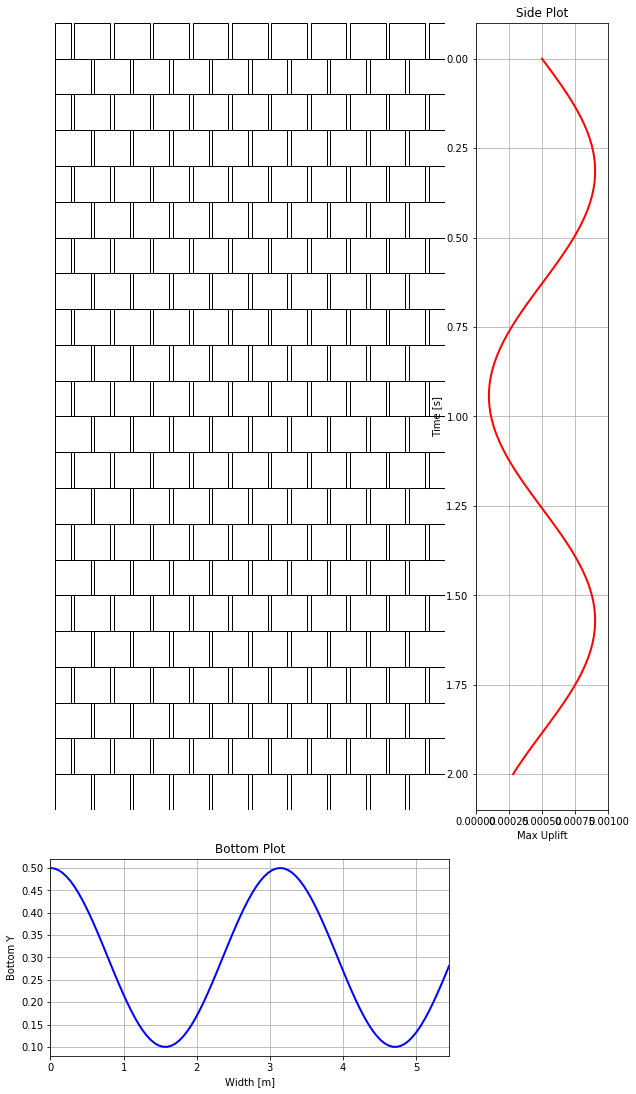

✅ Saved: block_grid_with_correct_width_bottom_plot.png


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np

# ------------------------------
# Dummy data for the plots
# ------------------------------

# Uplift data for side plot
times = np.linspace(0, 2, 100)
max_uplift = np.sin(times * 5) * 0.0004 + 0.0005   # dummy data

# Data for bottom plot
bottom_x = np.linspace(0, 5.45, 100)    # matches grid width!
bottom_y = np.cos(bottom_x * 2) * 0.2 + 0.3

# ------------------------------
# Compute grid width
# ------------------------------

# Block grid parameters
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
horizontal_spacing = 0.05

# Compute width of full block rows
grid_width = (10 * full_w) + (9 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

# ------------------------------
# Figure with gridspec
# ------------------------------

fig = plt.figure(figsize=(10, 19))

# 2 rows, 2 columns grid:
#   - top left: block grid
#   - top right: side plot
#   - bottom left: bottom plot
#   - bottom right: empty
gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[4, 1],
    wspace=0.1,
    hspace=0.1
)

# === TOP LEFT AXES (block grid) ===
ax_grid = fig.add_subplot(gs[0, 0])

# Draw block grid
rows = 22
current_y = 0

for row in range(rows):
    if row % 2 == 0:
        # Even row: 10 full blocks
        for i in range(10):
            x = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle((x, current_y), full_w, full_h,
                                     edgecolor='black', facecolor='white')
            ax_grid.add_patch(rect)
    else:
        x = 0
        # First half block
        rect = patches.Rectangle((x, current_y), half_w, half_h,
                                 edgecolor='black', facecolor='white')
        ax_grid.add_patch(rect)
        x += half_w + horizontal_spacing
        # 9 full blocks
        for i in range(9):
            rect = patches.Rectangle((x, current_y), full_w, full_h,
                                     edgecolor='black', facecolor='white')
            ax_grid.add_patch(rect)
            x += full_w + horizontal_spacing
        # Final half block
        rect = patches.Rectangle((x, current_y), half_w, half_h,
                                 edgecolor='black', facecolor='white')
        ax_grid.add_patch(rect)

    current_y += full_h

# Configure block grid
ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, current_y)
ax_grid.axis('off')

# === TOP RIGHT AXES (side plot) ===
ax_side = fig.add_subplot(gs[0, 1])

ax_side.plot(max_uplift, times, color='red', linewidth=2)
ax_side.invert_yaxis()
ax_side.set_xlabel('Max Uplift')
ax_side.set_ylabel('Time [s]')
ax_side.set_xlim(0, 0.001)
ax_side.grid(True)
ax_side.set_title('Side Plot')

# === BOTTOM LEFT AXES (bottom plot) ===
ax_bottom = fig.add_subplot(gs[1, 0])

ax_bottom.plot(bottom_x, bottom_y, color='blue', linewidth=2)
ax_bottom.set_xlim(0, grid_width)
ax_bottom.set_xlabel('Width [m]')
ax_bottom.set_ylabel('Bottom Y')
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot')

# Leave bottom right empty (no subplot)

# Save and show
plt.tight_layout()
plt.savefig("block_grid_with_correct_width_bottom_plot.png", dpi=300)
plt.show()

print("✅ Saved: block_grid_with_correct_width_bottom_plot.png")


   Time  Signal
0  0.00     0.0
1  0.01     0.0
2  0.02     0.0
3  0.03     0.0
4  0.04     0.0
5  0.05     0.0
6  0.06     0.0
7  0.07     0.0
8  0.08     0.0
9  0.09     0.0
✅ CSV saved as time_signal.csv


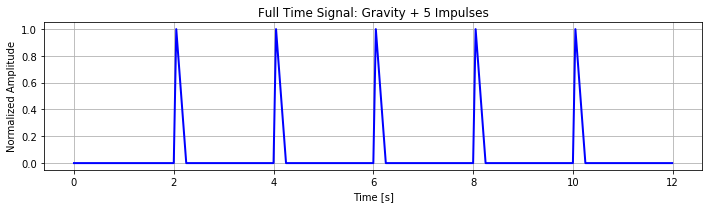

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Define single pulse shape ---
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

# --- Time signal setup ---
total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time = np.arange(0, end_time, dt)

signal = np.zeros_like(time)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time >= t_start) & (time <= t_start + pulse_duration)
    local_time = time[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

# --- Create DataFrame ---
df = pd.DataFrame({
    "Time": time,
    "Signal": signal
})

print(df.head(10))

# Optional: save to CSV
df.to_csv("time_signal.csv", index=False)
print("✅ CSV saved as time_signal.csv")

# Plot for confirmation
plt.figure(figsize=(10, 3))
plt.plot(df["Time"], df["Signal"], color='blue', linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Normalized Amplitude')
plt.title('Full Time Signal: Gravity + 5 Impulses')
plt.grid(True)
plt.tight_layout()
plt.show()


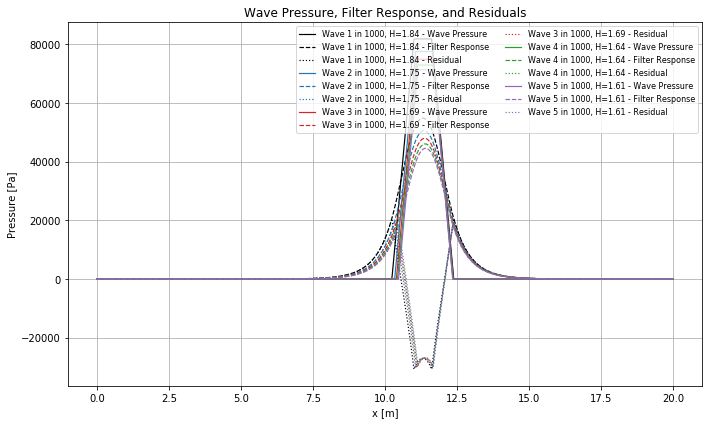

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.linalg import solve
import pandas as pd
from scipy.interpolate import interp1d
import os

Hs = 0.7

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)
H_wave_width = Hs

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate wave heights (Rayleigh) ---

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Initialize storage ---
block_pressures_per_wave = {}
residual_profiles = {}  
wave_pressures = {}
filter_responses = {}

# Loop through each wave

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[f"Wave {i+1} in 1000, H={H_wave:.2f}"] = block_avg_pressures

# Plot histogram of block pressures for each wave
plt.figure(figsize=(10, 6))

colors = ["black", "tab:blue", "tab:red", "tab:green", "tab:purple"]
linestyles = ["-", "--", ":"]

for idx, wave_name in enumerate(wave_pressures.keys()):
    color = colors[idx % len(colors)]
    plt.plot(x, wave_pressures[wave_name],
             linestyle=linestyles[0],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Wave Pressure")

    plt.plot(x, filter_responses[wave_name],
             linestyle=linestyles[1],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Filter Response")

    plt.plot(x, residual_profiles[wave_name],
             linestyle=linestyles[2],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Residual")

plt.xlabel("x [m]")
plt.ylabel("Pressure [Pa]")
plt.title("Wave Pressure, Filter Response, and Residuals")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


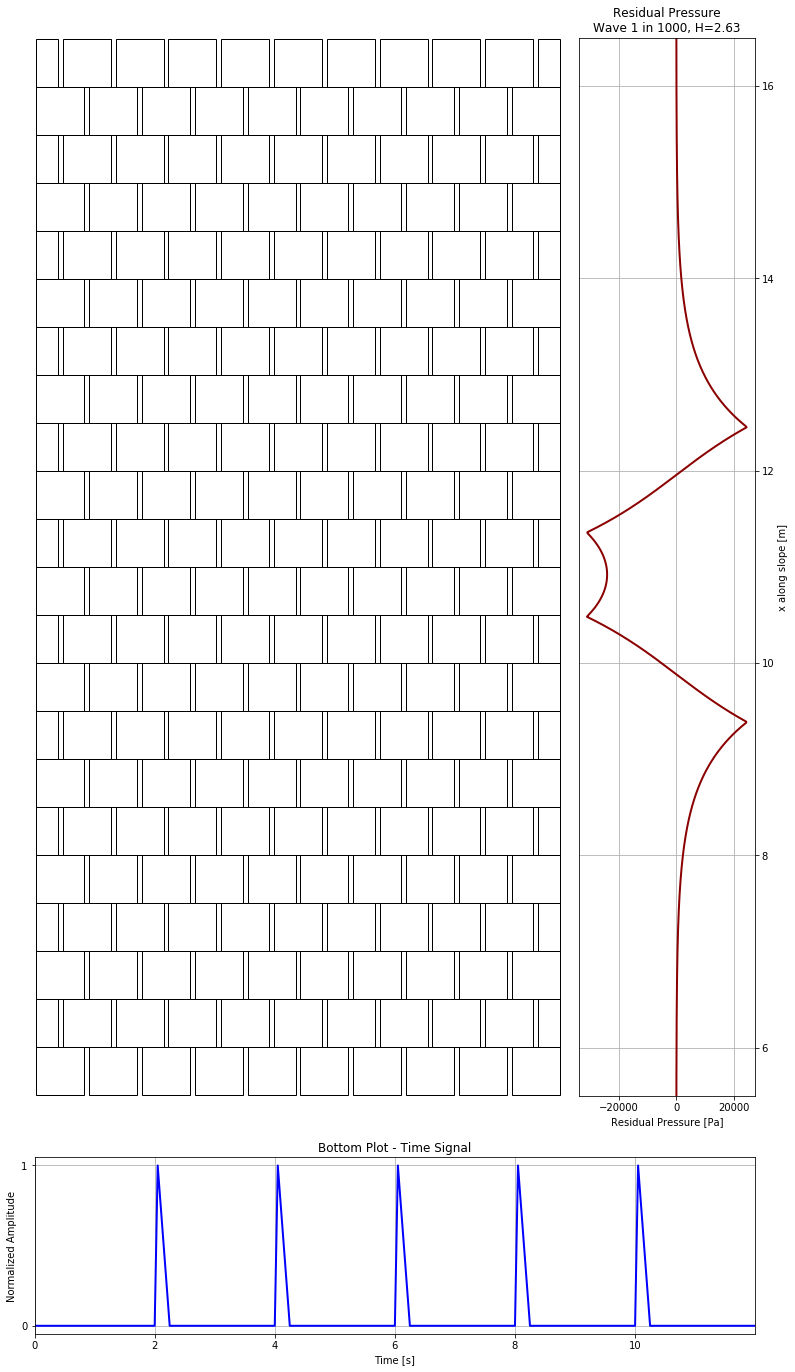

✅ Saved: block_grid_with_residual_pressure.png


In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.linalg import solve

# ------------------------------
# Wave simulation setup
# ------------------------------

Hs = 1.0

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)
H_wave_width = Hs

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate wave heights (Rayleigh) ---
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Initialize storage ---
block_pressures_per_wave = {}
residual_profiles = {}
wave_pressures = {}
filter_responses = {}

# Loop through each wave
for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[wave_name] = block_avg_pressures

# ------------------------------
# Create time signal for bottom plot
# ------------------------------

# --- Pulse signal ---
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

signal = np.zeros_like(time_signal)

for wave in range(total_waves):
    t_start = gravity_time + wave * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal[active] = pulse

df_signal = pd.DataFrame({
    "Time": time_signal,
    "Signal": signal
})

# ------------------------------
# Figure with gridspec
# ------------------------------

# Pick which wave to plot in right-side plot
# example:
wave_to_plot = list(residual_profiles.keys())[0]   # pick Wave 3, for example

fig = plt.figure(figsize=(10, 18))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.1
)

# === TOP LEFT AXES (block grid) ===
ax_grid = fig.add_subplot(gs[0, 0])

rows = 22
current_y = 0

for row in range(rows):
    if row % 2 == 0:
        for i in range(10):
            x_rect = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle(
                (x_rect, current_y), full_w, full_h,
                edgecolor='black', facecolor='white'
            )
            ax_grid.add_patch(rect)
    else:
        x_rect = 0
        rect = patches.Rectangle(
            (x_rect, current_y), half_w, half_h,
            edgecolor='black', facecolor='white'
        )
        ax_grid.add_patch(rect)
        x_rect += half_w + horizontal_spacing
        for i in range(9):
            rect = patches.Rectangle(
                (x_rect, current_y), full_w, full_h,
                edgecolor='black', facecolor='white'
            )
            ax_grid.add_patch(rect)
            x_rect += full_w + horizontal_spacing
        rect = patches.Rectangle(
            (x_rect, current_y), half_w, half_h,
            edgecolor='black', facecolor='white'
        )
        ax_grid.add_patch(rect)

    current_y += full_h

# Add margin
margin_x = 0.01
margin_y = 0.01

ax_grid.set_aspect('equal')
ax_grid.set_xlim(-margin_x, grid_width + margin_x)
ax_grid.set_ylim(-margin_y, current_y + margin_y)
ax_grid.axis('off')

# === TOP RIGHT AXES (side plot) ===
ax_side = fig.add_subplot(gs[0, 1])

# Plot residual vs. x
ax_side.plot(residual_profiles[wave_to_plot], x,
             color='darkred', linewidth=2)
ax_side.invert_yaxis()
ax_side.set_xlabel('Residual Pressure [Pa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)  # Adjust limits for clarity
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title(f"Residual Pressure\n{wave_to_plot}")
ax_side.grid(True)

# === BOTTOM AXES (bottom plot spanning both columns) ===
ax_bottom = fig.add_subplot(gs[1, :])

ax_bottom.plot(df_signal["Time"], df_signal["Signal"],
               color='blue', linewidth=2)
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Normalized Amplitude')
ax_bottom.set_yticks([0, 1])
ax_bottom.grid(True)
ax_bottom.set_title('Bottom Plot - Time Signal')

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

plt.savefig(
    "block_grid_with_residual_pressure.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)
plt.show()

print(f"✅ Saved: block_grid_with_residual_pressure.png")
